<a href="https://colab.research.google.com/github/mikysetiawan/MachineLearningExpert/blob/master/Tugas_Akhir_Timeseries_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import STL

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import statsmodels.api as sm

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

df = pd.read_csv(csv_url, parse_dates=['Date'], index_col='Date')

df.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53150 entries, 2017-09-21 09:00:00.000 to 2023-10-19 23:00:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close        53150 non-null  float64
 1   Volume USDT  53150 non-null  float64
 2   RSI          53150 non-null  float64
 3   MACD_Hist    53150 non-null  float64
 4   ATR          53150 non-null  float64
 5   KAMAO        53150 non-null  float64
dtypes: float64(6)
memory usage: 2.8+ MB


Checking null value

In [6]:
# Check the number of missing values in each column
df.isnull().sum()

,0
Close,0
Volume USDT,0
RSI,0
MACD_Hist,0
ATR,0
KAMAO,0


Trying rolling mean to denoised data

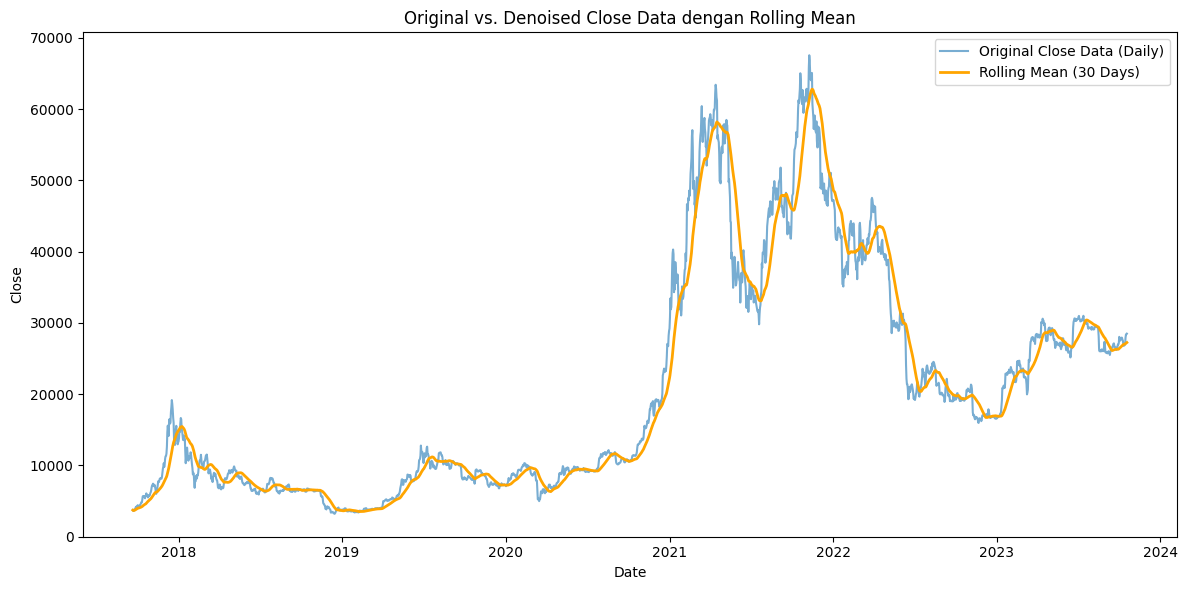

In [32]:
# Change index datatype to datetime
df.index = pd.to_datetime(df.index, format='mixed')

# Resample dataset into daily
df_daily = df.resample('D').mean()

# Run rolling mean with window 1 month
df_daily['Rolling_Mean'] = df_daily['Close'].rolling(window=30, min_periods=1).mean()

# Show in figure
plt.figure(figsize=(12, 6))
plt.plot(df_daily.index, df_daily['Close'], label='Original Close Data (Daily)', alpha=0.6)
plt.plot(df_daily.index, df_daily['Rolling_Mean'], label='Rolling Mean (30 Days)', color='orange', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Original vs. Denoised Close Data dengan Rolling Mean')
plt.legend()
plt.tight_layout()
plt.show()

# ========== EDA =============

Seasonal and Trend decomposition using Loess

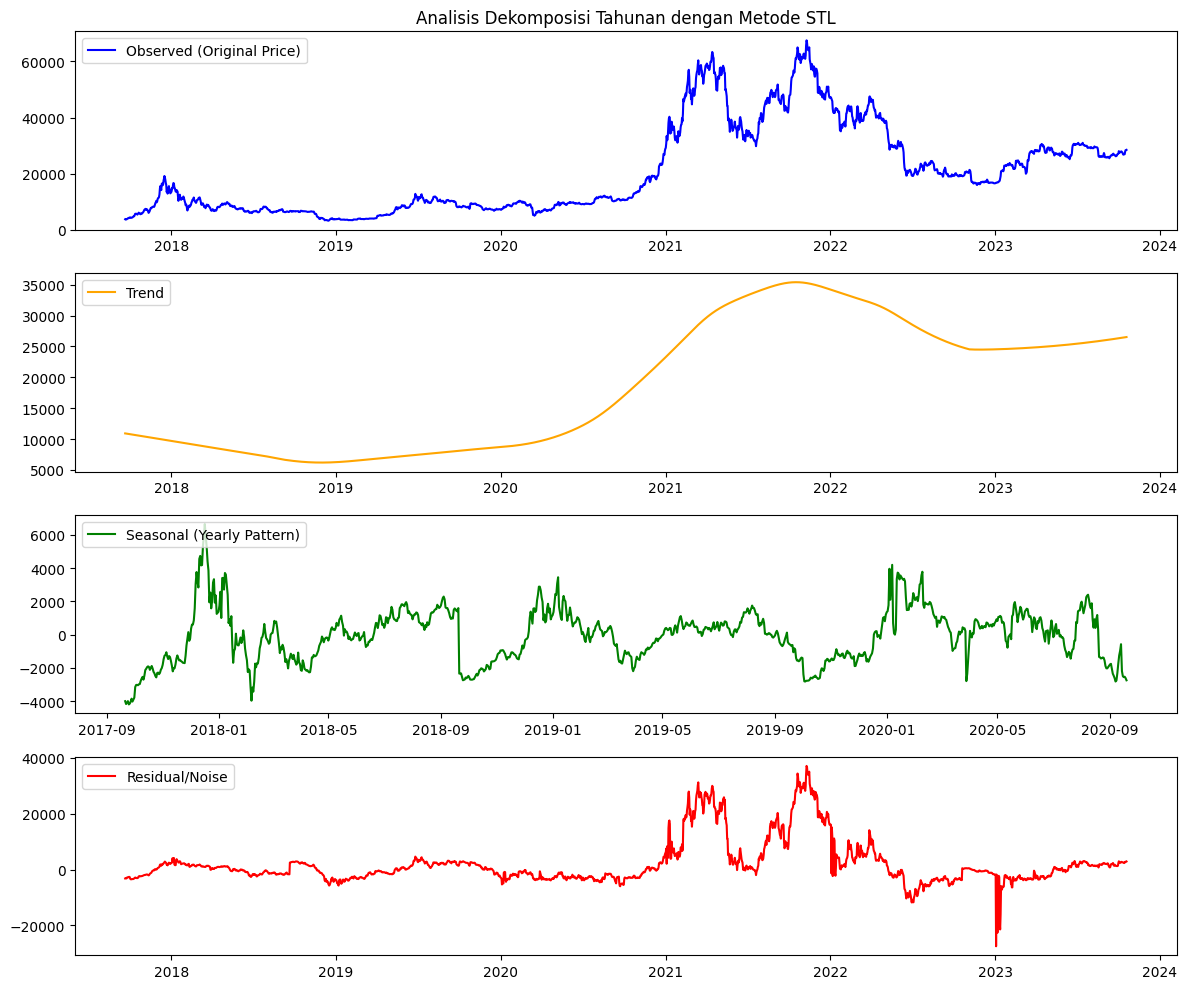

In [41]:
# Hitung dekomposisi dari data 'Close' asli
stl = STL(df_daily['Close'], period=365, robust=True)
decomposition = stl.fit()

plt.figure(figsize=(12, 10))

# 1. Observed
plt.subplot(411)
plt.plot(df_daily.index, decomposition.observed, label='Observed (Original Price)', color='blue')
plt.legend(loc='upper left')
plt.title('Analisis Dekomposisi Tahunan dengan Metode STL')

# 2. Trend
plt.subplot(412)
plt.plot(df_daily.index, decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

# 3. Seasonal (Menampilkan grafik 3 tahun pertama = 1095 hari untuk melihat polanya)
plt.subplot(413)
plt.plot(df_daily.index[:1095], decomposition.seasonal[:1095], label='Seasonal (Yearly Pattern)', color='green')
plt.legend(loc='upper left')

# 4. Residual
plt.subplot(414)
plt.plot(df_daily.index, decomposition.resid, label='Residual/Noise', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Check stationary data with ADF

In [42]:
def adf_test(series):
    result = adfuller(series, autolag='AIC')

    print("ADF Test Results:")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data stasioner")
    else:
        print("Data tidak stasioner")

adf_test(df_daily['Close'])

ADF Test Results:
ADF Statistic: -1.6046699303660317
p-value: 0.4812472214825565
Data tidak stasioner


In [43]:
print("===== adf test Volume USDT ==========")
adf_test(df_daily['Volume USDT'])
print("===== adf test RSI ==========")
adf_test(df_daily['RSI'])
print("===== adf test MACD_Hist ==========")
adf_test(df_daily['MACD_Hist'])
print("===== adf test ATR ==========")
adf_test(df_daily['ATR'])
print("===== adf test KAMAO ==========")
adf_test(df_daily['KAMAO'])

===== adf test Volume USDT ==========
ADF Test Results:
ADF Statistic: -2.5591517493503995
p-value: 0.10173702908268628
Data tidak stasioner
===== adf test RSI ==========
ADF Test Results:
ADF Statistic: -7.8902327069787015
p-value: 4.456777095991523e-12
Data stasioner
===== adf test MACD_Hist ==========
ADF Test Results:
ADF Statistic: -9.476871873398707
p-value: 3.9678779953515675e-16
Data stasioner
===== adf test ATR ==========
ADF Test Results:
ADF Statistic: -2.095753317673501
p-value: 0.24622563908704503
Data tidak stasioner
===== adf test KAMAO ==========
ADF Test Results:
ADF Statistic: -13.736739530515125
p-value: 1.1137102887237336e-25
Data stasioner


In [44]:
# Buat DataFrame baru khusus untuk fitur model forecasting
df_features = pd.DataFrame(index=df_daily.index)

# 1. Transformasi target harga (gunakan Close atau Rolling Mean Anda)
# Diubah menjadi persentase return harian agar stasioner sempurna
df_features['Close'] = df_daily['Close'].pct_change()

# 2. Transformasi Volume USDT (Gunakan pct_change karena tidak stasioner)
df_features['Volume USDT'] = df_daily['Volume USDT'].pct_change()

# 3. Transformasi ATR (Gunakan Log + Diff karena varians tidak konstan)
df_features['ATR'] = np.log(df_daily['ATR']).diff()

# 4. Kolom yang sudah lolos (Stasioner) langsung dimasukkan tanpa diubah
df_features['RSI'] = df_daily['RSI']
df_features['MACD_Hist'] = df_daily['MACD_Hist']
df_features['KAMAO'] = df_daily['KAMAO']

# Wajib gunakan .dropna() karena efek .diff() dan .pct_change() menyisakan nilai kosong di baris paling awal
df_features.dropna(inplace=True)

# ---- PEMBUKTIAN ----
# Mari kita uji ulang apakah DataFrame baru ini sudah 100% stasioner semuanya
print("=== VERIFIKASI AKHIR DATASET STASIONER ===")
for col in df_features.columns:
    print(f"\n===== adf test {col} =====")
    adf_test(df_features[col])


=== VERIFIKASI AKHIR DATASET STASIONER ===

===== adf test Close =====
ADF Test Results:
ADF Statistic: -30.1814716587699
p-value: 0.0
Data stasioner

===== adf test Volume USDT =====
ADF Test Results:
ADF Statistic: -8.8937934497929
p-value: 1.222311599749406e-14
Data stasioner

===== adf test ATR =====
ADF Test Results:
ADF Statistic: -9.078198316189676
p-value: 4.124015003454134e-15
Data stasioner

===== adf test RSI =====
ADF Test Results:
ADF Statistic: -7.891747476533741
p-value: 4.4175856535305675e-12
Data stasioner

===== adf test MACD_Hist =====
ADF Test Results:
ADF Statistic: -9.47242399331453
p-value: 4.0725312605919312e-16
Data stasioner

===== adf test KAMAO =====
ADF Test Results:
ADF Statistic: -13.732415208971595
p-value: 1.1336138863944295e-25
Data stasioner


ACF & PACF

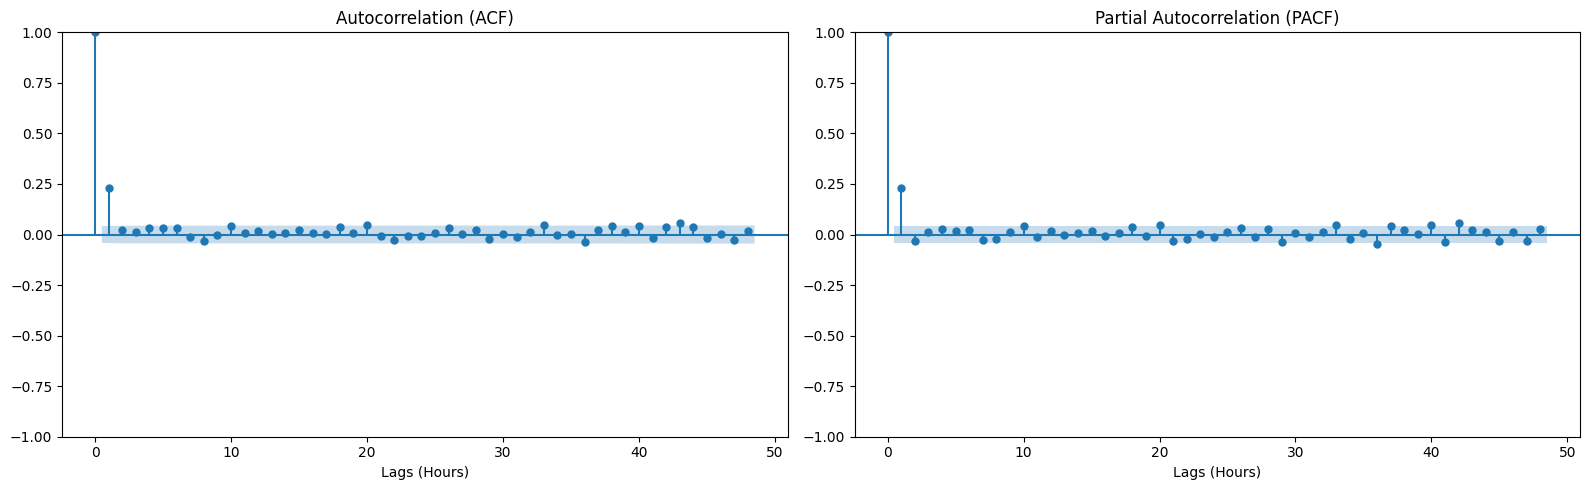

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(df_features['Close'], lags=48, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
axes[0].set_xlabel('Lags (Hours)')

# Plot Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(df_features['Close'], lags=48, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')
axes[1].set_xlabel('Lags (Hours)')

plt.tight_layout()
plt.show()

Membuat fitur rolling standard deviation per 30 hari

In [49]:
# Membuat fitur baru: Volatilitas harga berbasis Rolling Standard Deviation 30 hari
df_features['Close_Volatilitas_30d'] = df_features['Close'].rolling(window=30).std()

# Karena rolling menyebabkan data pertama menjadi NaN, kita isi dengan metode bfill
df_features['Close_Volatilitas_30d'] = df_features['Close_Volatilitas_30d'].bfill()

print("Daftar fitur baru yang siap digunakan:")
print(df_features.head())

Daftar fitur baru yang siap digunakan:
               Close  Volume USDT       ATR        RSI  MACD_Hist     KAMAO  \
Date                                                                          
2017-09-22 -0.030415    -0.276462 -0.014535  48.408477 -51.151407 -0.334452   
2017-09-23  0.028970    -0.076544 -0.025565  48.854844 -50.649339  0.907334   
2017-09-24 -0.008986    -0.126413 -0.028514  48.778774 -41.864028  0.403087   
2017-09-25  0.037833     0.138353 -0.030959  49.362802 -32.004721  2.057620   
2017-09-26  0.022333    -0.259673 -0.029267  49.710639 -11.581613  2.860377   

            Close_Volatilitas_24h  Close_Volatilitas_30d  
Date                                                      
2017-09-22               0.030267               0.030748  
2017-09-23               0.030267               0.030748  
2017-09-24               0.030267               0.030748  
2017-09-25               0.030267               0.030748  
2017-09-26               0.030267               0.030

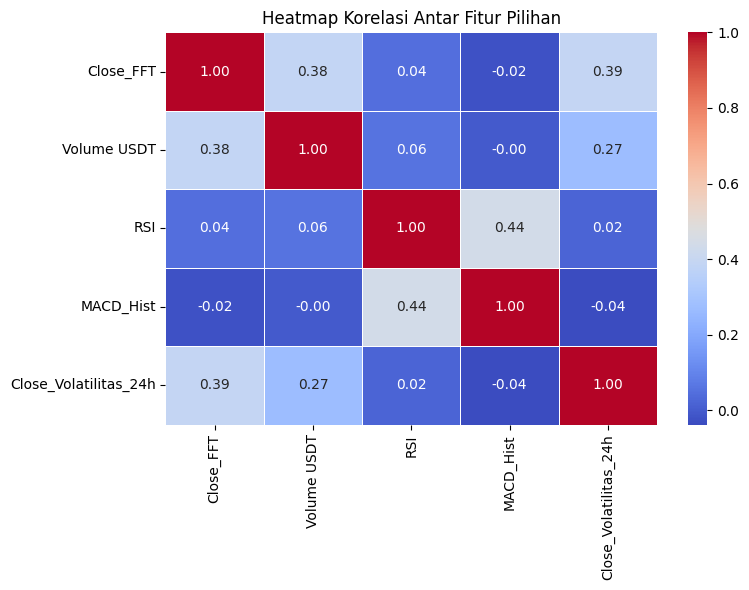

In [13]:
plt.figure(figsize=(8, 6))
# Menghitung korelasi antar fitur pilihan
correlation_matrix = df_filtered.corr()

# Membuat Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Pilihan')
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(df['Close_FFT'], lags=48, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
axes[0].set_xlabel('Lags (Hours)')

# Plot Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(df['Close_FFT'], lags=48, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')
axes[1].set_xlabel('Lags (Hours)')

plt.tight_layout()
plt.show()

In [ ]:
def create_dataset(dataset, time_step=24):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        # Mengambil semua 4 fitur sebagai input
        X.append(dataset[i:(i + time_step), :])
        # Target prediksi: Close_FFT di jam berikutnya (kolom indeks 0)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Menggunakan window 24 jam ke belakang
TIME_STEP = 24
X_train, y_train = create_dataset(train_scaled, TIME_STEP)
X_test, y_test = create_dataset(test_scaled, TIME_STEP)

print("Shape X_train:", X_train.shape) # Harus berupa (samples, 24, 4)
print("Shape y_train:", y_train.shape)

Shape X_train: (42495, 24, 4)
Shape y_train: (42495,)


In [ ]:
# 1. Inisialisasi Model LSTM Dasar
model = Sequential([
    # input_shape=(time_steps, num_features) -> (24, 4)
    LSTM(units=50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(units=1)
])

# 2. Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# 3. Training Model Baseline
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0013 - val_loss: 1.8021e-05
Epoch 2/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 1.6222e-05 - val_loss: 1.4231e-05
Epoch 3/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 1.2772e-05 - val_loss: 1.0389e-05
Epoch 4/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 1.0117e-05 - val_loss: 7.7601e-06
Epoch 5/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 9.5750e-06 - val_loss: 8.4180e-06
Epoch 6/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 7.3762e-06 - val_loss: 8.0997e-06
Epoch 7/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 6.0121e-06 - val_loss: 3.9129e-06
Epoch 8/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 4.9948e-06 - val_loss: 3.4993e-06
Epoch 9/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 4.9823e-06 - val_loss: 4.6301e-06
Epoch 10/10
664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 3.5807e-06 - val_loss: 3.4257e-06
